In [91]:
# Imports necesarios para el notebook
import random

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from collections import deque 
from greedy import greedy_monedas

from util import time_algorithm

# Siempre seteamos la seed de aleatoridad para que los # resultados sean reproducibles
random.seed(12345)
np.random.seed(12345)

sns.set_theme()

In [92]:
x = np.linspace(100, 100_000, 20).astype(int)

def get_random_cant_monedas(s):
    # devuelve un array aleatorio de numeros mayores a 0 
    return [random.randint(1, 5000) for _ in range(s)]


results = time_algorithm(greedy_monedas, x, lambda s: [get_random_cant_monedas(s)])

print(results)

{np.int64(100): 0.0, np.int64(5357): 0.0016003847122192383, np.int64(10615): 0.0031954050064086914, np.int64(15873): 0.003911638259887695, np.int64(21131): 0.005902004241943359, np.int64(26389): 0.006801056861877442, np.int64(31647): 0.0059131145477294925, np.int64(36905): 0.007907247543334961, np.int64(42163): 0.010397076606750488, np.int64(47421): 0.011401772499084473, np.int64(52678): 0.012835049629211425, np.int64(57936): 0.014398574829101562, np.int64(63194): 0.015602493286132812, np.int64(68452): 0.015406632423400879, np.int64(73710): 0.017407035827636717, np.int64(78968): 0.02220292091369629, np.int64(84226): 0.020099687576293945, np.int64(89484): 0.02210545539855957, np.int64(94742): 0.021710681915283202, np.int64(100000): 0.03797814846038818}


Text(0, 0.5, 'Tiempo de ejecución (s)')

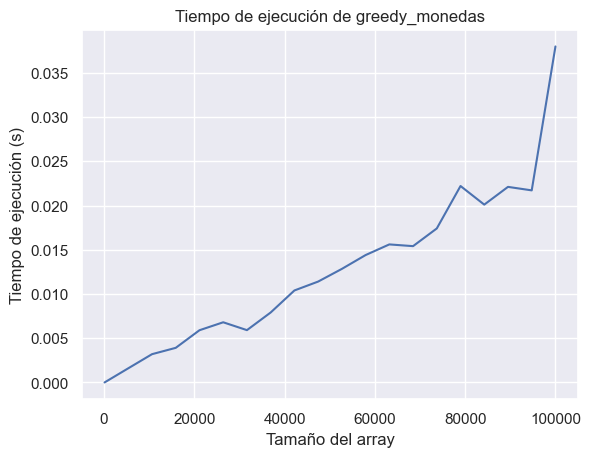

In [93]:
ax: plt.Axes
fig, ax = plt.subplots()
ax.plot(x, [results[i] for i in x], label="Medición")
ax.set_title('Tiempo de ejecución de greedy_monedas')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Tiempo de ejecución (s)')


In [94]:
# scipy nos pide una función que recibe primero x y luego los parámetros a ajustar:
f = lambda x, c1, c2: c1 * x * np.log(x) + c2 

c, pcov = sp.optimize.curve_fit(f, x, [results[n] for n in x])

print(f"c_1 = {c[0]}, c_2 = {c[1]}")
r = np.sum((c[0] * x * np.log(x) + c[1] - [results[n] for n in x])**2)
print(f"Error cuadrático total: {r}")

c_1 = 2.400911927689812e-08, c_2 = -0.0004273712448837465
Error cuadrático total: 0.00016232392599333794


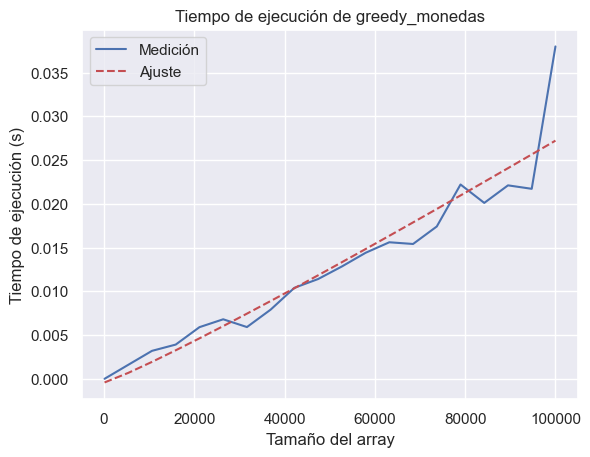

In [95]:
ax.plot(x, [c[0] * n * np.log(n) + c[1] for n in x], 'r--', label="Ajuste")
ax.legend()
fig

Text(0, 0.5, 'Error absoluto (s)')

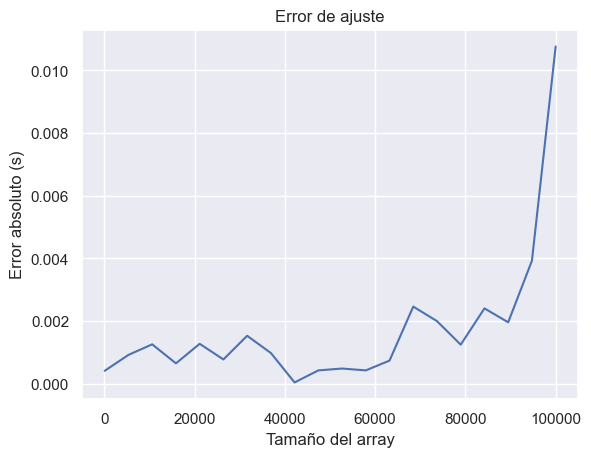

In [96]:
ax: plt.Axes
fig, ax = plt.subplots()
errors = [np.abs(c[0] * n * np.log(n) + c[1] - results[n]) for n in x]
ax.plot(x, errors)
ax.set_title('Error de ajuste')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Error absoluto (s)')

In [97]:
def maximo_iter(datos):
    max_pos = 0
    for i in range(1, len(datos)):
        if datos[i] > datos[max_pos]:
            max_pos = i
    return datos[max_pos]

def maximo_dyc(datos, inicio, fin):
    if inicio == fin:
        return datos[inicio]

    medio = (inicio + fin) // 2
    izq = maximo_dyc(datos, inicio, medio)
    der = maximo_dyc(datos, medio + 1, fin)
    return izq if izq > der else der

In [98]:
# Tamaño mínimo, tamaño máximo, cantidad de puntos
x = np.linspace(100, 10_000_000, 20).astype(int)

In [99]:
results_iter = time_algorithm(maximo_iter, x, lambda s: [get_random_cant_monedas(s)])

BrokenProcessPool: A child process terminated abruptly, the process pool is not usable anymore

In [ ]:
results_dyc = time_algorithm(maximo_dyc, x, lambda s: [get_random_cant_monedas(s), 0, s - 1])

In [ ]:
f_lin = lambda x, c1, c2: c1 * x + c2
c_iter, _ = sp.optimize.curve_fit(f_lin, x, [results_iter[n] for n in x])
c_dyc, _ = sp.optimize.curve_fit(f_lin, x, [results_dyc[n] for n in x])

print(f"Algoritmo iterativo: c_1 = {c_iter[0]}, c_2 = {c_iter[1]}")
print(f"Algoritmo división y conquista: c_1 = {c_dyc[0]}, c_2 = {c_dyc[1]}")

In [ ]:
axs: tuple[plt.Axes, plt.Axes]
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axs[0].plot(x, [results_iter[n] for n in x], label="Medición")
axs[0].plot(x, [f_lin(n, c_iter[0], c_iter[1]) for n in x], 'r--', label=f"Ajuste lineal ($c_1 = {c_iter[0] :.2e}$)")
axs[0].set_title('Tiempo de ejecución de maximo_iter')
axs[0].set_xlabel('Tamaño del array')
axs[0].set_ylabel('Tiempo de ejecución (s)')
axs[0].legend()

axs[1].plot(x, [results_dyc[n] for n in x], label="Medición")
axs[1].plot(x, [f_lin(n, c_dyc[0], c_dyc[1]) for n in x], 'r--', label=f"Ajuste lineal ($c_1 = {c_dyc[0] :.2e}$)")
axs[1].set_title('Tiempo de ejecución de maximo_dyc')
axs[1].set_xlabel('Tamaño del array')
axs[1].legend()